In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandasql import sqldf
from graphviz import Digraph
from IPython.display import Image

from matplotlib.lines import Line2D

In [2]:
pysqldf = lambda q: sqldf(q,globals())

In [3]:
df_train = pd.read_csv("train.csv")
df_holiday = pd.read_csv("holidays_events.csv")
df_oil = pd.read_csv("oil.csv")
df_stores = pd.read_csv("stores.csv")
df_trans = pd.read_csv("transactions.csv")

## Block diagram

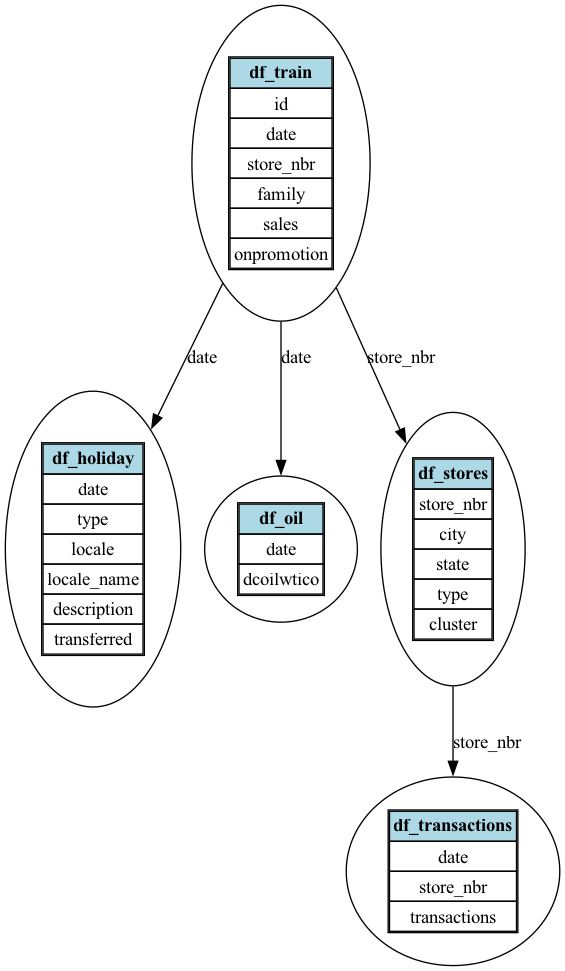

In [10]:

def table_node(name, columns, color="lightblue"):
    header = f'<TR><TD BGCOLOR="{color}" COLSPAN="1"><B>{name}</B></TD></TR>'
    rows = "".join(f"<TR><TD>{col}</TD></TR>" for col in columns)
    return f"""<
    <TABLE BORDER="1" CELLBORDER="1" CELLSPACING="0">
    {header}
    {rows}
    </TABLE>
    >"""

dot = Digraph(comment='Database Tables Relationship Diagram')

# Add nodes
tables = {
    "df_train": df_train.columns,
    "df_holiday": df_holiday.columns,
    "df_oil": df_oil.columns,
    "df_stores": df_stores.columns,
    "df_transactions": df_trans.columns
}

for name, cols in tables.items():
    dot.node(name, table_node(name, cols))

# Add edges
dot.edge("df_train", "df_holiday", label="date")
dot.edge("df_train", "df_oil", label="date")
dot.edge("df_train", "df_stores", label="store_nbr")
dot.edge("df_stores", "df_transactions", label="store_nbr")

# Display directly in notebook
Image(dot.pipe(format="png"))


In [36]:
## Convert all dates to datetime format

df_train['date'] = pd.to_datetime(df_train['date'])
df_oil['date']= pd.to_datetime(df_oil['date'])
df_holiday['date']=pd.to_datetime(df_holiday['date'])
df_trans['date']=pd.to_datetime(df_trans['date'])

## Understanding Data

In [39]:
display(df_train.head(5))
display(df_holiday.head(5))
display(df_oil.head(5))
display(df_stores.head(5))
display(df_trans.head(5))

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [7]:
print("====\ntrain :",df_train.isna().any())
print("====\nHoliday_data \n",df_holiday.isna().any())
print("====\noil_data \n",df_oil.isna().any())
print("====\nstores_data \n",df_stores.isna().any())
print("====\ntrans_data \n",df_trans.isna().any())

====
train : id             False
date           False
store_nbr      False
family         False
sales          False
onpromotion    False
dtype: bool
====
Holiday_data 
 date           False
type           False
locale         False
locale_name    False
description    False
transferred    False
dtype: bool
====
oil_data 
 date          False
dcoilwtico     True
dtype: bool
====
stores_data 
 store_nbr    False
city         False
state        False
type         False
cluster      False
dtype: bool
====
trans_data 
 date            False
store_nbr       False
transactions    False
dtype: bool


In [8]:
print("Duplicates")
print("====\ntrain :",df_train.duplicated().any())
print("====\nHoliday_data \n",df_holiday.duplicated().any())
print("====\noil_data \n",df_oil.duplicated().any())
print("====\nstores_data \n",df_stores.duplicated().any())
print("====\ntrans_data \n",df_trans.duplicated().any())

Duplicates
====
train : False
====
Holiday_data 
 False
====
oil_data 
 False
====
stores_data 
 False
====
trans_data 
 False


In [17]:
df_holiday[df_holiday['date'].duplicated(keep=False)]

,date,type,locale,locale_name,description,transferred
7,2012-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False
8,2012-06-25,Holiday,Local,Latacunga,Cantonizacion de Latacunga,False
9,2012-06-25,Holiday,Local,Machala,Fundacion de Machala,False
10,2012-07-03,Holiday,Local,Santo Domingo,Fundacion de Santo Domingo,False
11,2012-07-03,Holiday,Local,El Carmen,Cantonizacion de El Carmen,False
...,...,...,...,...,...,...
319,2017-07-03,Holiday,Local,Santo Domingo,Fundacion de Santo Domingo,False
341,2017-12-08,Holiday,Local,Loja,Fundacion de Loja,False
342,2017-12-08,Transfer,Local,Quito,Traslado Fundacion de Quito,False
344,2017-12-22,Holiday,Local,Salinas,Cantonizacion de Salinas,False


In [34]:
df_train['date']=pd.to_datetime(df_train['date'])
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


In [11]:
df_train.nunique()

id             3000888
date              1684
store_nbr           54
family              33
sales           379610
onpromotion        362
dtype: int64

To understand the data we need to look into what are the major features the affects the sales.
We combine multiple tables and see what story  it tells.

In [12]:
query = "select * from df_train where onpromotion is not 0"
pysqldf(query)

,id,date,store_nbr,family,sales,onpromotion
0,810784,2014-04-01,9,CLEANING,1752.00000,3
1,810789,2014-04-01,9,GROCERY I,7685.00000,5
2,812571,2014-04-02,9,GROCERY I,6481.00000,3
3,812587,2014-04-02,9,POULTRY,613.71704,1
4,814346,2014-04-03,9,BREAD/BAKERY,521.00000,1
...,...,...,...,...,...,...
611324,3000877,2017-08-15,9,"LIQUOR,WINE,BEER",25.00000,2
611325,3000880,2017-08-15,9,PERSONAL CARE,522.00000,11
611326,3000884,2017-08-15,9,PREPARED FOODS,154.55300,1
611327,3000885,2017-08-15,9,PRODUCE,2419.72900,148


What is the total sales from all stores change over time?

<Axes: title={'center': 'Total Sales Over Time'}, xlabel='date'>

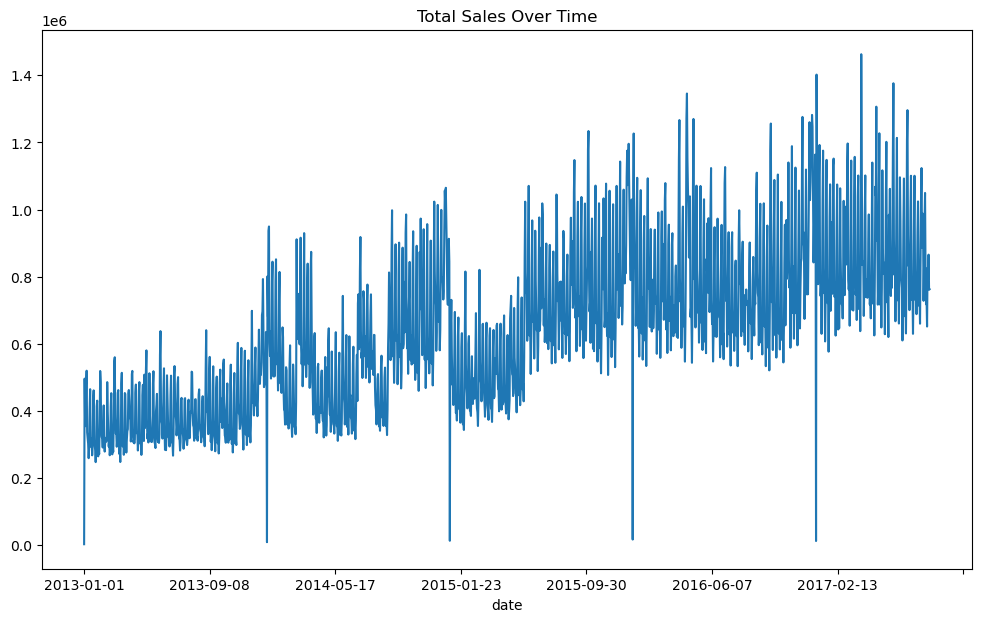

In [ ]:
df_train.groupby("date")["sales"].sum().plot(figsize=(12,7), title="Total Sales Over Time")

In [14]:
print(len(df_holiday))
df_holiday['type'].value_counts()

350


type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64

There are 350 special days. Lets plot it over sales plot and see whether they affected the sales on those days.

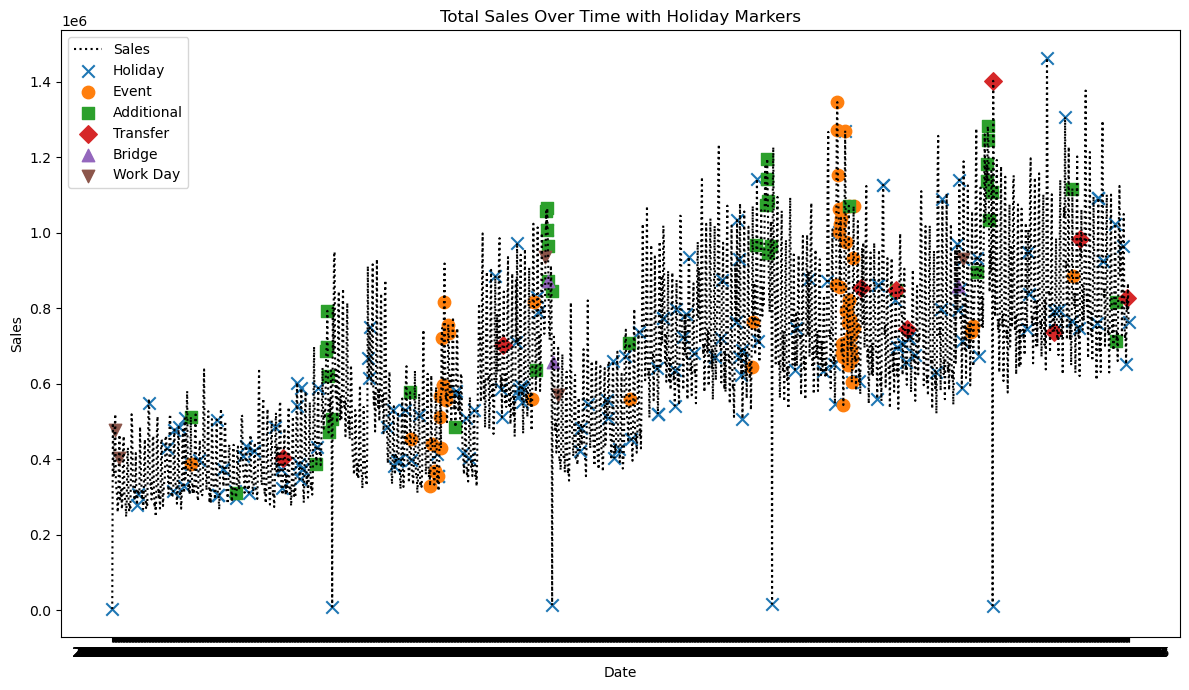

In [15]:
query = """
    SELECT t.date, sum(sales) AS sales, h.type
    FROM df_train
    LEFT JOIN  df_holidays
    ON t.date=h.date
    group by t.date
"""



sales_ts = df_train.groupby("date")["sales"].sum().reset_index()

# Merge with holiday data
sales_with_holidays = pd.merge(sales_ts, df_holiday[["date", "type"]],
                                on="date", how="left")

# Marker mapping for holiday types
marker_map = {
    "Holiday": "x",
    "Event": "o",
    "Additional": "s",
    "Transfer": "D",
    "Bridge": "^",
    "Work Day": "v"
}

# Plot the main sales line
plt.figure(figsize=(12,7))
plt.plot(sales_with_holidays["date"], sales_with_holidays["sales"],
         ls=":", color="black", label="Sales")

# Overlay markers for each holiday type
for htype, marker in marker_map.items():
    subset = sales_with_holidays[sales_with_holidays["type"] == htype]
    plt.scatter(subset["date"], subset["sales"],
                marker=marker, label=htype, s=80)

# Beautify plot
plt.title("Total Sales Over Time with Holiday Markers")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
# plt.grid(True)
plt.tight_layout()
plt.show()

we could see multiple event happening on the same day. THis is because we havent taken of locale of the holiday.
It could be a National or regional event.The regional event will have effect on the sales of the stores in a given region.
Lets see what happens in the case of a store located at a particular area.

In [25]:
## Unique cities and states 
# print(df_stores['city'].value_counts())
# print(df_stores['state'].value_counts())
# print(df_holiday['locale_name'].value_counts())
uni_cities = df_stores['city'].unique()
uni_state = df_stores['state'].unique()
uni_locale = df_holiday['locale_name'].unique()

print(np.intersect1d(uni_cities,uni_locale))
print(np.intersect1d(uni_state,uni_locale))
print(np.intersect1d(uni_cities,uni_state))
query = """
    SELECT t.*, s.
"""

['Ambato' 'Cayambe' 'Cuenca' 'El Carmen' 'Esmeraldas' 'Guaranda'
 'Guayaquil' 'Ibarra' 'Latacunga' 'Libertad' 'Loja' 'Machala' 'Manta'
 'Puyo' 'Quevedo' 'Quito' 'Riobamba' 'Salinas' 'Santo Domingo']
['Cotopaxi' 'Esmeraldas' 'Imbabura' 'Loja' 'Santa Elena'
 'Santo Domingo de los Tsachilas']
['Esmeraldas' 'Loja']


we have both city-wise and state-wise holidays. Also on certain holidays the sales completely zero. We need to check what is special about this holidays

In [40]:
df_holiday["description"].unique()

array(['Fundacion de Manta', 'Provincializacion de Cotopaxi',
       'Fundacion de Cuenca', 'Cantonizacion de Libertad',
       'Cantonizacion de Riobamba', 'Cantonizacion del Puyo',
       'Cantonizacion de Guaranda', 'Provincializacion de Imbabura',
       'Cantonizacion de Latacunga', 'Fundacion de Machala',
       'Fundacion de Santo Domingo', 'Cantonizacion de El Carmen',
       'Cantonizacion de Cayambe', 'Fundacion de Esmeraldas',
       'Primer Grito de Independencia', 'Fundacion de Riobamba',
       'Fundacion de Ambato', 'Fundacion de Ibarra',
       'Cantonizacion de Quevedo', 'Independencia de Guayaquil',
       'Traslado Independencia de Guayaquil', 'Dia de Difuntos',
       'Independencia de Cuenca', 'Provincializacion de Santo Domingo',
       'Provincializacion Santa Elena', 'Independencia de Guaranda',
       'Independencia de Latacunga', 'Independencia de Ambato',
       'Fundacion de Quito-1', 'Fundacion de Quito', 'Fundacion de Loja',
       'Navidad-4', 'Cantonizac

In [16]:
query = """SELECT t.date, sum(t.sales) as sales"""

df_holiday[df_holiday.type=="Holiday"][["type","locale","locale_name"]].value_counts()

type     locale    locale_name                   
Holiday  National  Ecuador                           60
         Local     Ambato                            12
                   Guaranda                          12
                   Latacunga                         12
                   Riobamba                          12
                   Puyo                               6
         Regional  Santa Elena                        6
                   Imbabura                           6
                   Cotopaxi                           6
         Local     Santo Domingo                      6
                   Salinas                            6
                   Quito                              6
                   Quevedo                            6
                   Manta                              6
                   Cayambe                            6
                   Machala                            6
                   Loja                               

We have three types of holidays: city wise, state wise and National. Lets understand importance of locale of the holidays on sales. 

In [43]:
query =""" SELECT t.date,  sum(t.sales) as sales,h.type,h.locale
FROM df_train t
LEFT JOIN df_holiday h 
ON t.date=h.date 
GROUP BY t.date,  h.type, h.locale"""

df_plot = pysqldf(query)


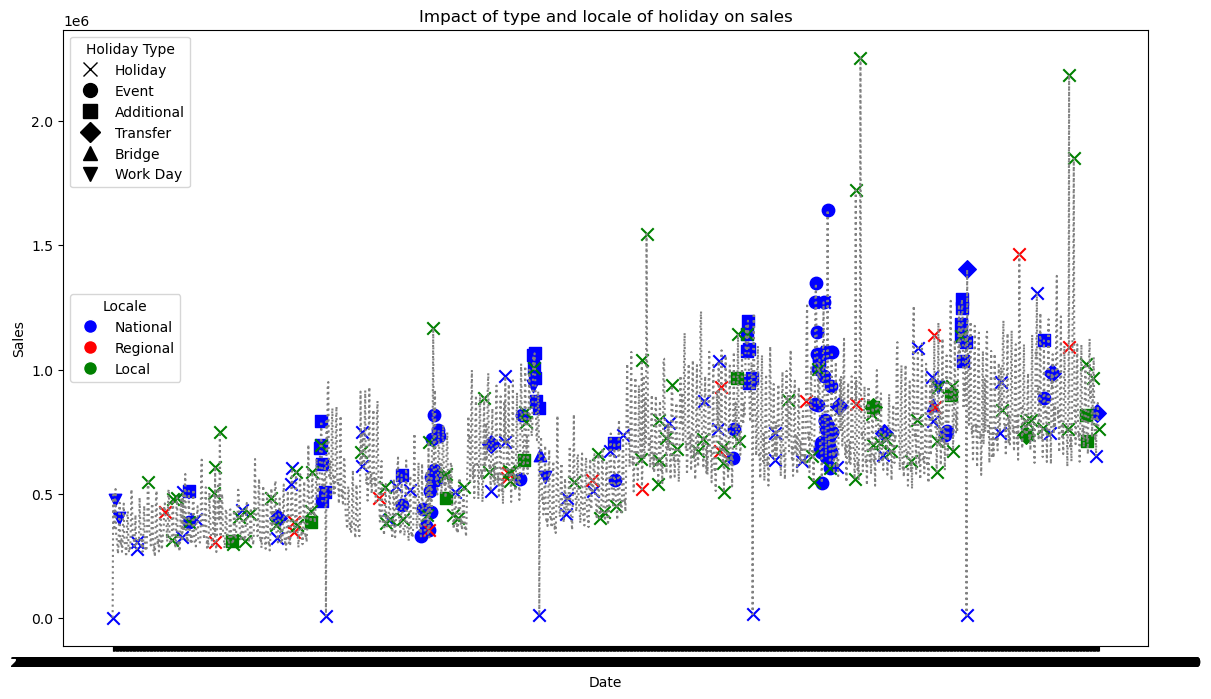

In [51]:
color_map = {
    "National":"blue",
    "Regional":"red",
    "Local":"green"

}
marker_map = {
    "Holiday": "x",
    "Event": "o",
    "Additional": "s",
    "Transfer": "D",
    "Bridge": "^",
    "Work Day": "v"
}
plt.figure(figsize=(14,8))
plt.plot(df_plot['date'],df_plot['sales'],ls=":",color="grey")
for locale,color in color_map.items():
    for type,marker in marker_map.items():
        df_subset = df_plot[(df_plot["locale"]==locale) & (df_plot['type']==type)]
        plt.scatter(df_subset['date'],df_subset['sales'],color=color,marker=marker,s=80)

# Legend for event types (markers)
marker_handles = [
    Line2D([0], [0], marker=m, color='w', linestyle='None',
           label=label, markerfacecolor='black', markeredgecolor='black', markersize=10)
    for label, m in marker_map.items()
]

# Legend for locales (colors)
color_handles = [
    Line2D([0], [0], marker='o', color='w', linestyle='None',
           label=label, markerfacecolor=c, markersize=10)
    for label, c in color_map.items()
]

# Add legends separately
legend1 = plt.legend(handles=marker_handles, title="Holiday Type", loc="upper left")
plt.gca().add_artist(legend1)  # Keep first legend
plt.legend(handles=color_handles, title="Locale", loc="center left")

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Impact of type and locale of holiday on sales")
plt.show()

Here we can see that different type of holidays have different effects on sales. For instance, type additional shows an increase in sales on the corresponding dates whereas the national holidays has relatively lower sales with respective the adjacent dates. Therefore these two features can be considered for hierarchical variables in a pymc model.

We can see multiple markers on the same day. This is because different regions have local holiday on the same date. 

In [38]:
df_plot[df_plot["date"].duplicated(keep=False)]

,date,sales,type,locale
131,2013-05-12 00:00:00.000000,3.878605e+05,Event,National
132,2013-05-12 00:00:00.000000,3.878605e+05,Holiday,Local
176,2013-06-25 00:00:00.000000,6.102391e+05,Holiday,Local
177,2013-06-25 00:00:00.000000,3.051195e+05,Holiday,Regional
357,2013-12-22 00:00:00.000000,6.962951e+05,Additional,National
358,2013-12-22 00:00:00.000000,6.962951e+05,Holiday,Local
542,2014-06-25 00:00:00.000000,3.553424e+05,Event,National
543,2014-06-25 00:00:00.000000,7.106848e+05,Holiday,Local
544,2014-06-25 00:00:00.000000,3.553424e+05,Holiday,Regional
724,2014-12-22 00:00:00.000000,1.008143e+06,Additional,National


Text(0.5, 1.0, 'Top 5 Product Families - Sales Over Time')

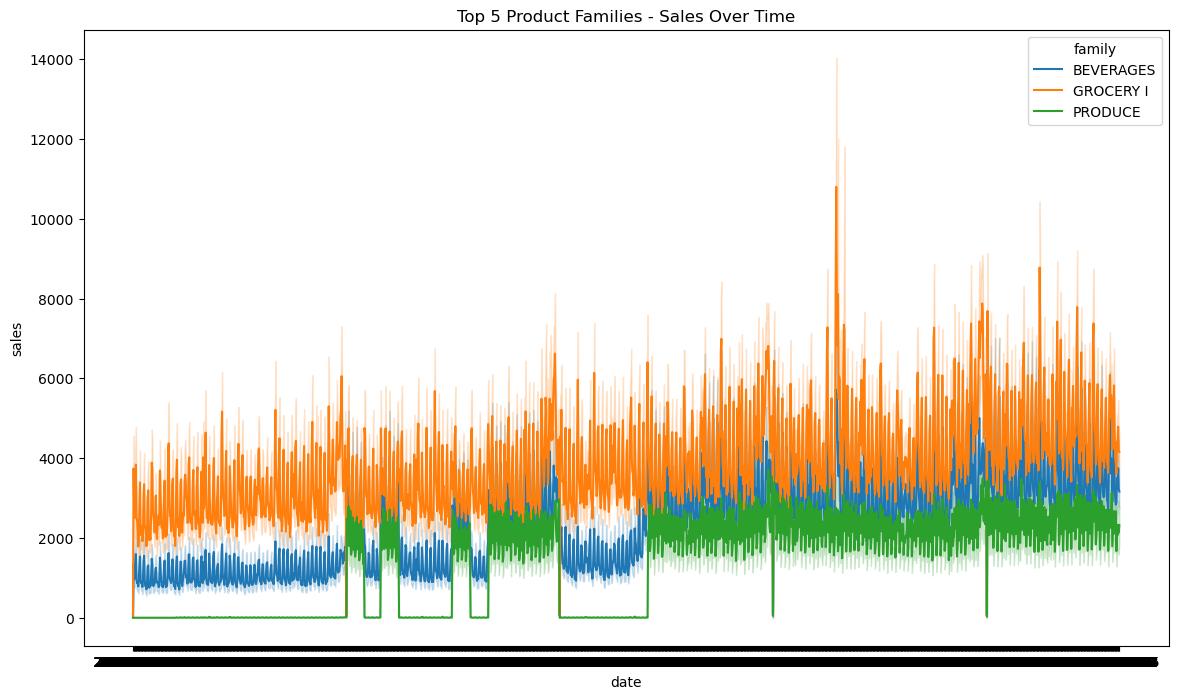

In [27]:
import seaborn as sns

top_families = df_train.groupby("family")["sales"].sum().nlargest(3).index

plt.figure(figsize=(14,8))
sns.lineplot(data=df_train[df_train["family"].isin(top_families)],
             x="date", y="sales", hue="family").set_title("Top 5 Product Families - Sales Over Time")


<Axes: title={'center': 'Sales vs Oil Price'}, xlabel='date'>

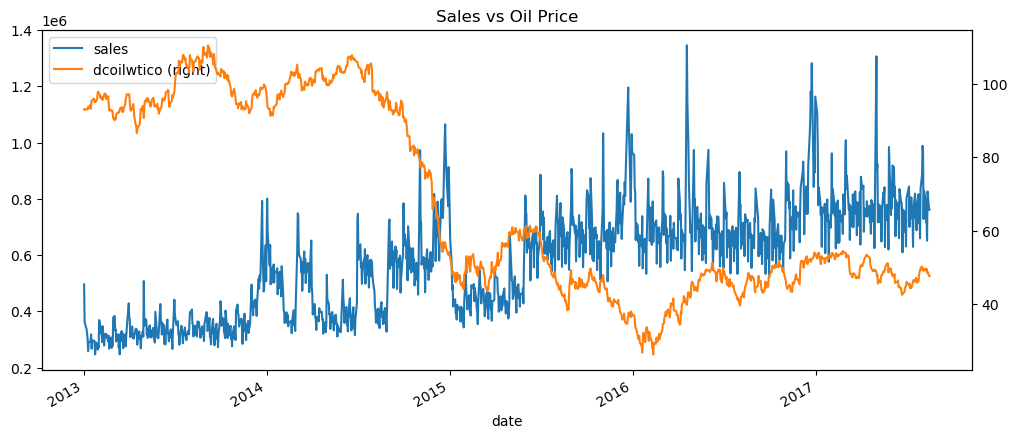

In [48]:
# df_oil["date"] = pd.to_datetime(df_oil["date"])
# df_oil.set_index("date", inplace=True)
df_sales = df_train.groupby("date")["sales"].sum()
df_sales.index = pd.to_datetime(df_sales.index)
df_combined = pd.concat([df_sales, df_oil["dcoilwtico"]], axis=1).dropna()
df_combined.plot(secondary_y="dcoilwtico", figsize=(12,5), title="Sales vs Oil Price")


Here we can see a direct negative correlation with oil price and sales. Therefore in our anallysis we should consider the oil price in our dataset. Lets combine the important features from other datasets and create the preliminary table for training

In [54]:
df_train[df_train.sales >0]['family'].value_counts()

family
BREAD/BAKERY                  83606
BEVERAGES                     83605
MEATS                         83605
CLEANING                      83605
DAIRY                         83605
DELI                          83605
EGGS                          83605
GROCERY I                     83604
PERSONAL CARE                 83602
POULTRY                       83592
PREPARED FOODS                83585
FROZEN FOODS                  83578
GROCERY II                    79921
AUTOMOTIVE                    79310
LINGERIE                      76344
LIQUOR,WINE,BEER              74690
SEAFOOD                       73332
BEAUTY                        67036
PRODUCE                       65151
HOME AND KITCHEN I            59431
HOME AND KITCHEN II           59369
HOME CARE                     53735
CELEBRATION                   51257
PLAYERS AND ELECTRONICS       50118
LAWN AND GARDEN               48392
HARDWARE                      47412
PET SUPPLIES                  41271
MAGAZINES            

SInce we have non zero sales data points for each family, we can retain it in the final dataset.

In [57]:
#combining df_train and stores
df_train = df_train.drop(columns='id')
query = """SELECT t.*, s.city, s.state,s.type,s.cluster
FROM df_train t
LEFT JOIN df_stores s
ON t.store_nbr=s.store_nbr"""

df_com1 = pysqldf(query)
df_com1


,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,2013-01-01 00:00:00.000000,1,AUTOMOTIVE,0.000,0,Quito,Pichincha,D,13
1,2013-01-01 00:00:00.000000,1,BABY CARE,0.000,0,Quito,Pichincha,D,13
2,2013-01-01 00:00:00.000000,1,BEAUTY,0.000,0,Quito,Pichincha,D,13
3,2013-01-01 00:00:00.000000,1,BEVERAGES,0.000,0,Quito,Pichincha,D,13
4,2013-01-01 00:00:00.000000,1,BOOKS,0.000,0,Quito,Pichincha,D,13
...,...,...,...,...,...,...,...,...,...
3000883,2017-08-15 00:00:00.000000,9,POULTRY,438.133,0,Quito,Pichincha,B,6
3000884,2017-08-15 00:00:00.000000,9,PREPARED FOODS,154.553,1,Quito,Pichincha,B,6
3000885,2017-08-15 00:00:00.000000,9,PRODUCE,2419.729,148,Quito,Pichincha,B,6
3000886,2017-08-15 00:00:00.000000,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,Quito,Pichincha,B,6


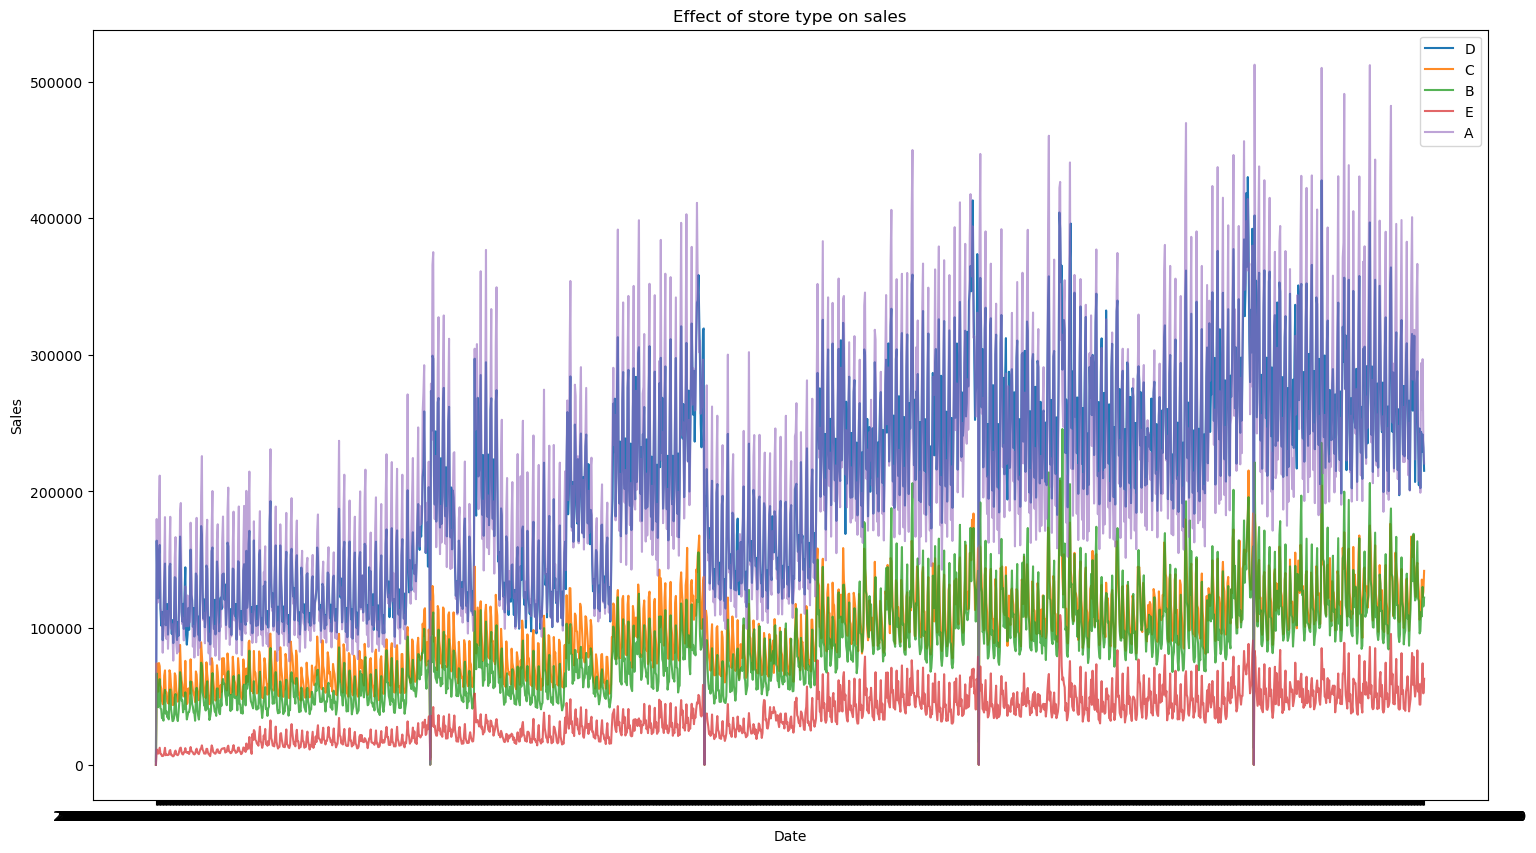

In [68]:
uni_type = df_com1.type.unique()
plt.figure(figsize=(18,10))
i=0
for type in uni_type:
    df_subset = df_com1[df_com1.type == type]
    df_temp = df_subset.groupby('date')['sales'].sum()
    plt.plot(df_temp.index,df_temp,label=type,alpha= 1- i*0.1)
    i=i+1
    # df_com1.groupby('date')['sales'].sum().plot(ls=":",figsize=(14,7),label=type)

plt.title ("Effect of store type on sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()


Here we can see clear a clear clusters in sales data where each type has different levels of baseline data, which this is an another candidate that can be a hierarchical variable in a PyMC model.

Let check the effect of cluster on sales

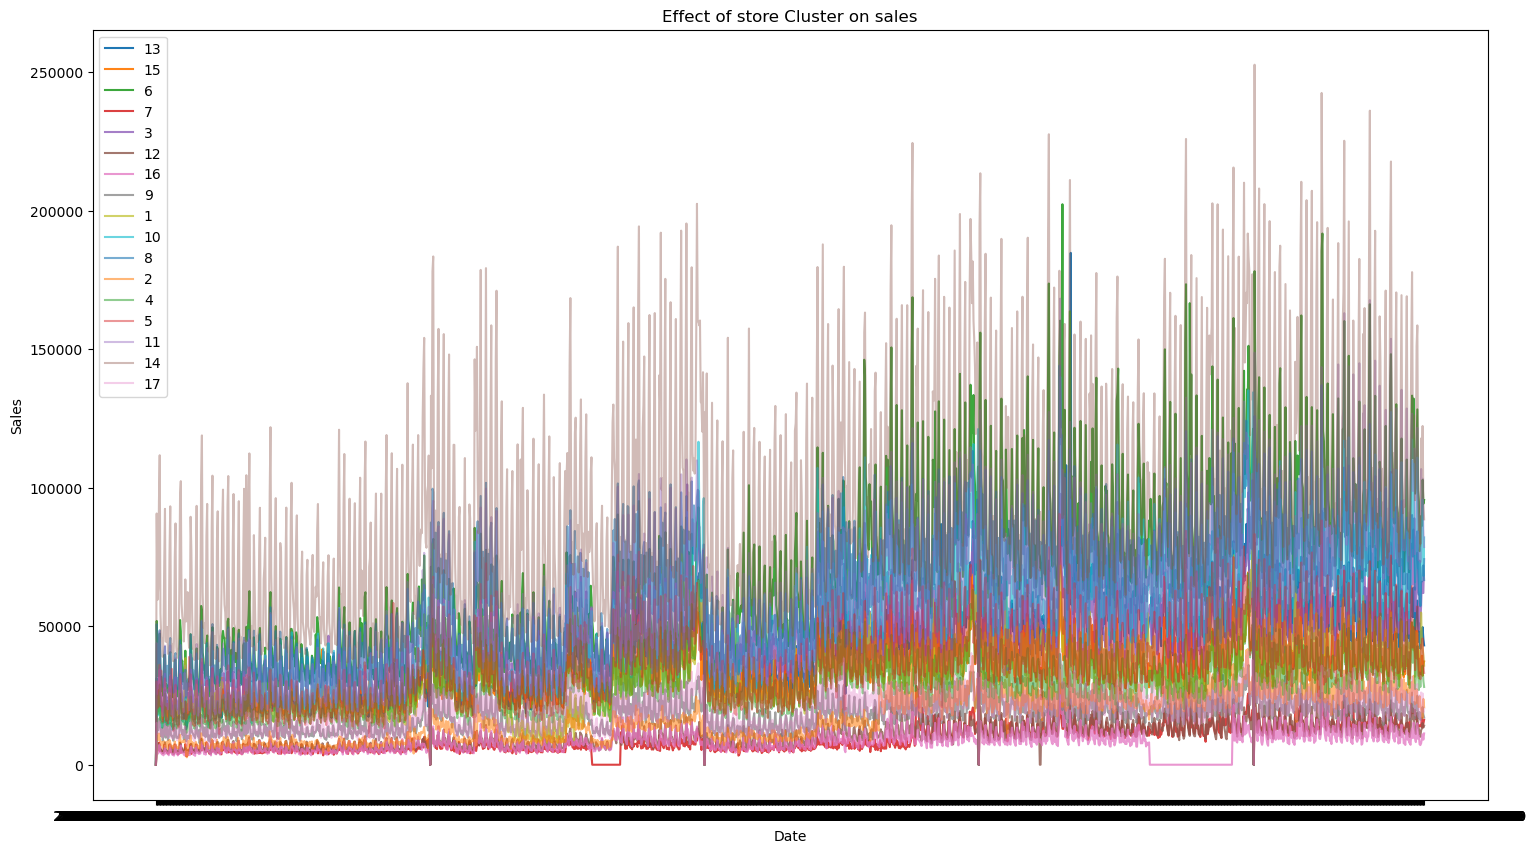

In [73]:
uni_cluster = df_com1.cluster.unique()
plt.figure(figsize=(18,10))
i=0
for cluster in uni_cluster:
    df_subset = df_com1[df_com1.cluster == cluster]
    df_temp = df_subset.groupby('date')['sales'].sum()
    plt.plot(df_temp.index,df_temp,label=cluster,alpha= 1- i*0.04)
    i=i+1


plt.title ("Effect of store Cluster on sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

Looks very messy!!!

Most likely cluster might be the same information as the store type . Lets over plot both together and check.
It going to be super messy still lets see whether we will get any info.

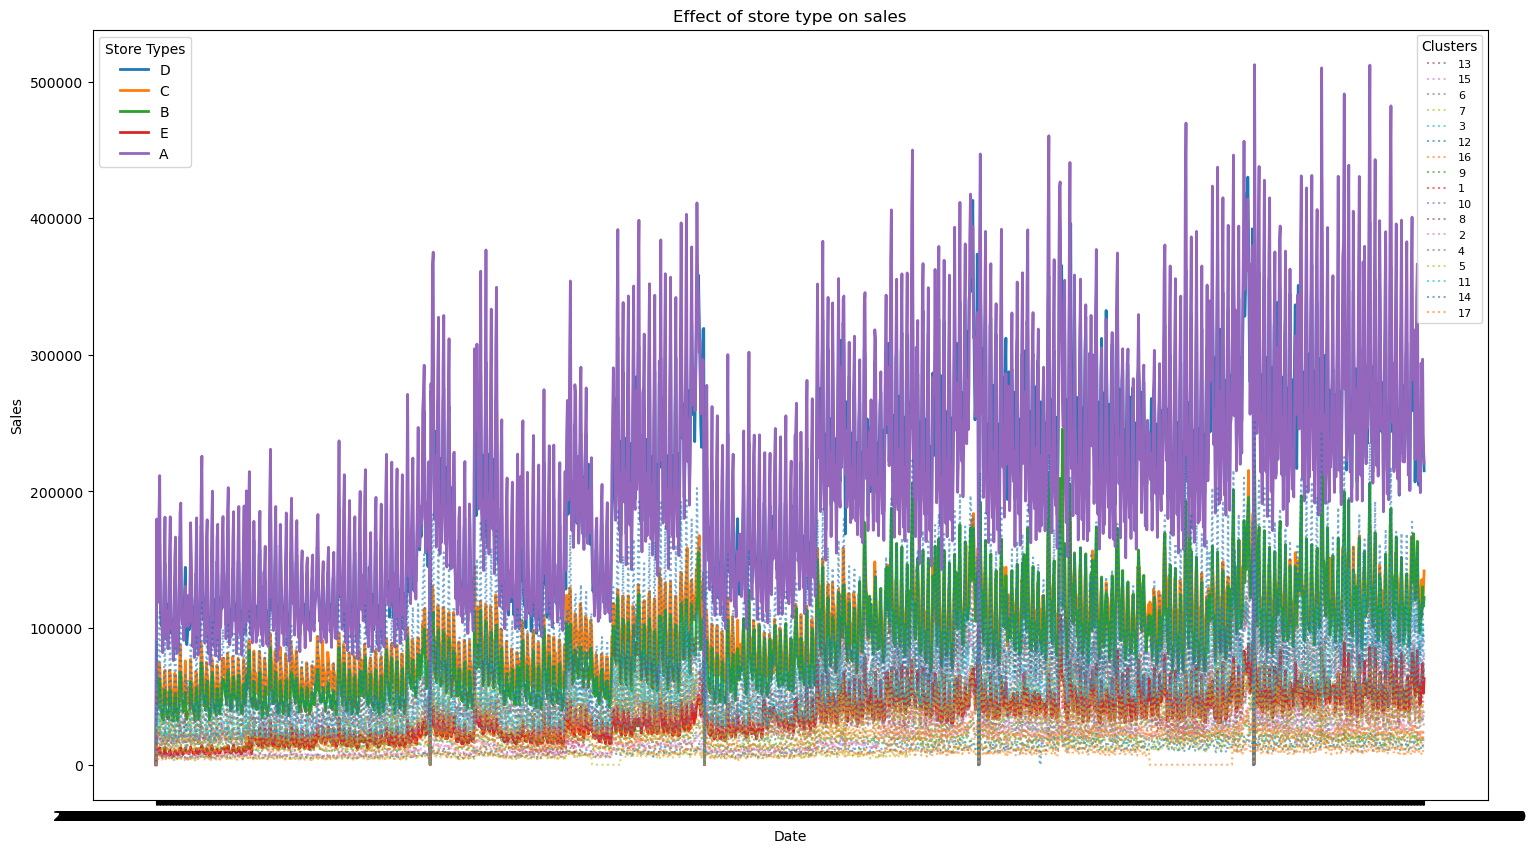

In [76]:
plt.figure(figsize=(18,10))

# Plot types (solid)
for i, type_ in enumerate(uni_type):
    df_temp = df_com1[df_com1.type == type_].groupby('date')['sales'].sum()
    plt.plot(df_temp.index, df_temp, label=type_, linewidth=2)

# Plot clusters (dotted, lighter)
for i, cluster in enumerate(uni_cluster):
    df_temp = df_com1[df_com1.cluster == cluster].groupby('date')['sales'].sum()
    plt.plot(df_temp.index, df_temp, ls=':', label=cluster, alpha=0.6)

plt.title("Effect of store type on sales")
plt.xlabel("Date")
plt.ylabel("Sales")

# Separate legends
handles, labels = plt.gca().get_legend_handles_labels()
type_handles = handles[:len(uni_type)]
type_labels = labels[:len(uni_type)]
cluster_handles = handles[len(uni_type):]
cluster_labels = labels[len(uni_type):]

first_legend = plt.legend(type_handles, type_labels, title="Store Types", loc='upper left')
plt.gca().add_artist(first_legend)
plt.legend(cluster_handles, cluster_labels, title="Clusters", loc='upper right', fontsize=8)

plt.show()


Looks like clusters dont provide much information gain. To some extent it is same info as type. To keep the model simple we can drop clusters in the final dataset

In [84]:
df_com2 = df_com1.drop(columns='cluster')
df_com2.columns

Index(['date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state',
       'type'],
      dtype='object')

In [80]:
df_holiday.columns

Index(['date', 'type', 'locale', 'locale_name', 'description', 'transferred'], dtype='object')

In [ ]:
query = """
SELECT 
    t.*,
    h.type AS holiday,
    h.locale
FROM df_com2 t
LEFT JOIN df_holiday h
    ON t.date = h.date
    AND (
        (h.locale = 'Local'    AND t.city  = h.locale_name)
        OR
        (h.locale = 'Regional' AND t.state = h.locale_name)
    )"""

df_com3 = pysqldf(query)
df_com3


,date,store_nbr,family,sales,onpromotion,city,state,type,holiday,locale
0,2013-01-01 00:00:00.000000,1,AUTOMOTIVE,0.000,0,Quito,Pichincha,D,None,None
1,2013-01-01 00:00:00.000000,1,BABY CARE,0.000,0,Quito,Pichincha,D,None,None
2,2013-01-01 00:00:00.000000,1,BEAUTY,0.000,0,Quito,Pichincha,D,None,None
3,2013-01-01 00:00:00.000000,1,BEVERAGES,0.000,0,Quito,Pichincha,D,None,None
4,2013-01-01 00:00:00.000000,1,BOOKS,0.000,0,Quito,Pichincha,D,None,None
...,...,...,...,...,...,...,...,...,...,...
3001147,2017-08-15 00:00:00.000000,9,POULTRY,438.133,0,Quito,Pichincha,B,None,None
3001148,2017-08-15 00:00:00.000000,9,PREPARED FOODS,154.553,1,Quito,Pichincha,B,None,None
3001149,2017-08-15 00:00:00.000000,9,PRODUCE,2419.729,148,Quito,Pichincha,B,None,None
3001150,2017-08-15 00:00:00.000000,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,Quito,Pichincha,B,None,None


Lets separate out date month and year from date

In [94]:
df_com3['date'] = pd.to_datetime(df_com3['date'])
df_com3['day'] = df_com3['date'].dt.day
df_com3['month'] = df_com3['date'].dt.month
df_com3['year'] = df_com3['date'].dt.year

df_com3

,date,store_nbr,family,sales,onpromotion,city,state,type,holiday,locale,day,month,year
0,2013-01-01,1,AUTOMOTIVE,0.000,0,Quito,Pichincha,D,None,None,1,1,2013
1,2013-01-01,1,BABY CARE,0.000,0,Quito,Pichincha,D,None,None,1,1,2013
2,2013-01-01,1,BEAUTY,0.000,0,Quito,Pichincha,D,None,None,1,1,2013
3,2013-01-01,1,BEVERAGES,0.000,0,Quito,Pichincha,D,None,None,1,1,2013
4,2013-01-01,1,BOOKS,0.000,0,Quito,Pichincha,D,None,None,1,1,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3001147,2017-08-15,9,POULTRY,438.133,0,Quito,Pichincha,B,None,None,15,8,2017
3001148,2017-08-15,9,PREPARED FOODS,154.553,1,Quito,Pichincha,B,None,None,15,8,2017
3001149,2017-08-15,9,PRODUCE,2419.729,148,Quito,Pichincha,B,None,None,15,8,2017
3001150,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,Quito,Pichincha,B,None,None,15,8,2017


We need to add oil prices to the dataframe.

In [95]:
query = """SELECT t.*, o.dcoilwtico as oil_price
FROM df_com3 t
LEFT JOIN df_oil o
ON t.date = o.date"""

df_com4 = pysqldf(query)
df_com4

,date,store_nbr,family,sales,onpromotion,city,state,type,holiday,locale,day,month,year,oil_price
0,2013-01-01 00:00:00.000000,1,AUTOMOTIVE,0.000,0,Quito,Pichincha,D,None,None,1,1,2013,NaN
1,2013-01-01 00:00:00.000000,1,BABY CARE,0.000,0,Quito,Pichincha,D,None,None,1,1,2013,NaN
2,2013-01-01 00:00:00.000000,1,BEAUTY,0.000,0,Quito,Pichincha,D,None,None,1,1,2013,NaN
3,2013-01-01 00:00:00.000000,1,BEVERAGES,0.000,0,Quito,Pichincha,D,None,None,1,1,2013,NaN
4,2013-01-01 00:00:00.000000,1,BOOKS,0.000,0,Quito,Pichincha,D,None,None,1,1,2013,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3001147,2017-08-15 00:00:00.000000,9,POULTRY,438.133,0,Quito,Pichincha,B,None,None,15,8,2017,47.57
3001148,2017-08-15 00:00:00.000000,9,PREPARED FOODS,154.553,1,Quito,Pichincha,B,None,None,15,8,2017,47.57
3001149,2017-08-15 00:00:00.000000,9,PRODUCE,2419.729,148,Quito,Pichincha,B,None,None,15,8,2017,47.57
3001150,2017-08-15 00:00:00.000000,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,Quito,Pichincha,B,None,None,15,8,2017,47.57


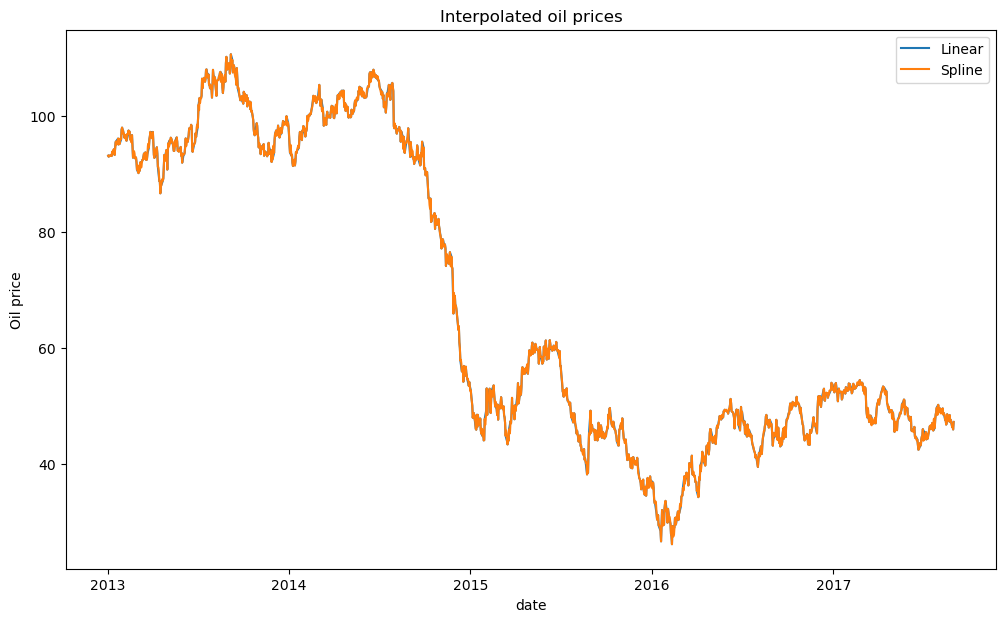

In [148]:
# df_oil_temp = df_com4[~df_com4[["date","oil_price"]].duplicated()][["date","oil_price"]]
full_dates = pd.date_range(start=df_oil['date'].min(),end=df_oil['date'].max(),freq='D')
df_oil_temp = pd.DataFrame({'date':full_dates})
query = """
SELECT ot.date, o.dcoilwtico as oil_price
FROM df_oil_temp ot
LEFT JOIN df_oil o
ON ot.date=o.date
"""
df_oil_temp= pysqldf(query)
# df_oil_temp
df_oil_temp.rename(columns={"dcoilwtico":"oil_price"},inplace=True)
df_oil_temp['date']= pd.to_datetime(df_oil_temp['date'])
df_oil_temp = df_oil_temp.sort_values('date')
df_oil_temp["linear"] = df_oil_temp['oil_price'].interpolate(method='linear')
df_oil_temp["spline"] = df_oil_temp["oil_price"].interpolate(method='spline',order=2)

plt.figure(figsize=(12,7))
plt.plot(df_oil_temp['date'],df_oil_temp['linear'],label='Linear')
plt.plot(df_oil_temp['date'],df_oil_temp['spline'],label='Spline')
plt.xlabel('date')
plt.ylabel('Oil price')
plt.title('Interpolated oil prices')
plt.legend()
plt.show()

In [153]:

df_oil_temp.loc[0,'linear']=df_oil_temp.loc[1,'linear']
df_oil_temp.loc[0,'spline']=df_oil_temp.loc[1,'spline']
df_oil_temp

,date,oil_price,linear,spline
0,2013-01-01,NaN,93.140000,93.140000
1,2013-01-02,93.14,93.140000,93.140000
2,2013-01-03,92.97,92.970000,92.970000
3,2013-01-04,93.12,93.120000,93.120000
4,2013-01-05,NaN,93.146667,93.047456
...,...,...,...,...
1699,2017-08-27,NaN,46.816667,46.967095
1700,2017-08-28,46.40,46.400000,46.400000
1701,2017-08-29,46.46,46.460000,46.460000
1702,2017-08-30,45.96,45.960000,45.960000


In [150]:
query = """
SELECT t.*, o.linear as oilprice_linear, o.spline as oilprice_spline
FROM df_com4 t
LEFT JOIN df_oil_temp o
ON t.date = o.date"""

df_com5 = pysqldf(query)
df_com5

,date,store_nbr,family,sales,onpromotion,city,state,type,holiday,locale,day,month,year,oil_price,oilprice_linear,oilprice_spline
0,2013-01-01 00:00:00.000000,1,AUTOMOTIVE,0.000,0,Quito,Pichincha,D,None,None,1,1,2013,NaN,93.14,93.14
1,2013-01-01 00:00:00.000000,1,BABY CARE,0.000,0,Quito,Pichincha,D,None,None,1,1,2013,NaN,93.14,93.14
2,2013-01-01 00:00:00.000000,1,BEAUTY,0.000,0,Quito,Pichincha,D,None,None,1,1,2013,NaN,93.14,93.14
3,2013-01-01 00:00:00.000000,1,BEVERAGES,0.000,0,Quito,Pichincha,D,None,None,1,1,2013,NaN,93.14,93.14
4,2013-01-01 00:00:00.000000,1,BOOKS,0.000,0,Quito,Pichincha,D,None,None,1,1,2013,NaN,93.14,93.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3001147,2017-08-15 00:00:00.000000,9,POULTRY,438.133,0,Quito,Pichincha,B,None,None,15,8,2017,47.57,47.57,47.57
3001148,2017-08-15 00:00:00.000000,9,PREPARED FOODS,154.553,1,Quito,Pichincha,B,None,None,15,8,2017,47.57,47.57,47.57
3001149,2017-08-15 00:00:00.000000,9,PRODUCE,2419.729,148,Quito,Pichincha,B,None,None,15,8,2017,47.57,47.57,47.57
3001150,2017-08-15 00:00:00.000000,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,Quito,Pichincha,B,None,None,15,8,2017,47.57,47.57,47.57


In [151]:
df_com5 = df_com5.drop(columns=['date','city','state'])
df_com5

,store_nbr,family,sales,onpromotion,type,holiday,locale,day,month,year,oil_price,oilprice_linear,oilprice_spline
0,1,AUTOMOTIVE,0.000,0,D,None,None,1,1,2013,NaN,93.14,93.14
1,1,BABY CARE,0.000,0,D,None,None,1,1,2013,NaN,93.14,93.14
2,1,BEAUTY,0.000,0,D,None,None,1,1,2013,NaN,93.14,93.14
3,1,BEVERAGES,0.000,0,D,None,None,1,1,2013,NaN,93.14,93.14
4,1,BOOKS,0.000,0,D,None,None,1,1,2013,NaN,93.14,93.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3001147,9,POULTRY,438.133,0,B,None,None,15,8,2017,47.57,47.57,47.57
3001148,9,PREPARED FOODS,154.553,1,B,None,None,15,8,2017,47.57,47.57,47.57
3001149,9,PRODUCE,2419.729,148,B,None,None,15,8,2017,47.57,47.57,47.57
3001150,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,B,None,None,15,8,2017,47.57,47.57,47.57


In [132]:
df_com5.to_csv('store_sales_time_series.csv')

## Data pipeline

In [155]:
df_test = pd.read_csv('test.csv')
df_test['date']=pd.to_datetime(df_test['date'])
query = """
SELECT
    t.*,
    s.city,
    s.state,
    s.type AS store_type,
    h.type AS holiday,
    h.locale,
    o.linear AS oilprice_linear,
    o.spline AS oilprice_spline
FROM df_test t
LEFT JOIN df_stores s
    ON t.store_nbr = s.store_nbr
LEFT JOIN df_holiday h
    ON t.date = h.date
    AND (
        (h.locale = 'Local'    AND s.city  = h.locale_name)
        OR
        (h.locale = 'Regional' AND s.state = h.locale_name)
    )
LEFT JOIN df_oil_temp o
    ON t.date = o.date
"""

df_com = pysqldf(query)

# Date parts
df_com['date'] = pd.to_datetime(df_com['date'])
df_com['day'] = df_com['date'].dt.day
df_com['month'] = df_com['date'].dt.month
df_com['year'] = df_com['date'].dt.year

# Drop unused columns
df_com = df_com.drop(columns=['id','date', 'city', 'state'])
df_com

,store_nbr,family,onpromotion,store_type,holiday,locale,oilprice_linear,oilprice_spline,day,month,year
0,1,AUTOMOTIVE,0,D,None,None,46.80,46.80,16,8,2017
1,1,BABY CARE,0,D,None,None,46.80,46.80,16,8,2017
2,1,BEAUTY,2,D,None,None,46.80,46.80,16,8,2017
3,1,BEVERAGES,20,D,None,None,46.80,46.80,16,8,2017
4,1,BOOKS,0,D,None,None,46.80,46.80,16,8,2017
...,...,...,...,...,...,...,...,...,...,...,...
28507,9,POULTRY,1,B,None,None,47.26,47.26,31,8,2017
28508,9,PREPARED FOODS,0,B,None,None,47.26,47.26,31,8,2017
28509,9,PRODUCE,1,B,None,None,47.26,47.26,31,8,2017
28510,9,SCHOOL AND OFFICE SUPPLIES,9,B,None,None,47.26,47.26,31,8,2017


In [156]:
df_com.to_csv('store_sales_time_series_test.csv')